# Grambank Morphosyntactic Complexity Mapped to UD

This dataset provides a **per-language morphological complexity index** from [Grambank v1.0.3](https://grambank.clld.org/) mapped to [Universal Dependencies](https://universaldependencies.org/) treebanks via ISO 639-3.

**Pipeline summary:**
1. Downloads Grambank CLDF data (values, parameters, languages) and feature domain classification
2. Identifies **87 morphology-relevant features** using authoritative domain classification (nominal/verbal/pronoun domains) plus known morphological codes
3. Computes a **complexity index** per language (proportion of present morphological features out of coded ones, min 15-feature threshold)
4. Maps languages to UD treebanks via Glottocode→ISO through Glottolog, with macro-language resolution

**Output:** 2,427 examples — 106 overlapping Grambank+UD, 2,253 Grambank-only, 68 UD-only. Index ranges from 0.08 (isolating, e.g. Mandarin) to 0.56 (inflected, e.g. Polish).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

## Load Data

Load the pre-computed Grambank morphosyntactic complexity dataset (mini subset for demo).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-42dac1-word-order-entropy-predicts-ordinal-tail/main/dataset_iter1_grambank_morpho/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples")

Loaded 35 examples


## Parse Examples into a DataFrame

Each example has an `input` (ISO 639-3 code), a JSON-encoded `output` (morph index + feature values), and metadata (language name, family, macroarea, UD treebanks, coordinates).

In [5]:
rows = []
for ex in examples:
    out = json.loads(ex["output"])
    rows.append({
        "iso3": ex["input"],
        "language": ex["metadata_language_name"],
        "family": ex["metadata_family_name"],
        "macroarea": ex["metadata_macroarea"],
        "fold": ex["metadata_fold"],
        "has_grambank": ex["metadata_has_grambank"],
        "has_ud": ex["metadata_has_ud"],
        "morph_index": out["grambank_morph_index"],
        "n_coded": out["n_morph_features_coded"],
        "n_present": out["n_morph_features_present"],
        "latitude": ex["metadata_latitude"],
        "longitude": ex["metadata_longitude"],
        "n_ud_treebanks": len(ex["metadata_ud_treebanks"]),
        "ud_treebanks": ", ".join(ex["metadata_ud_treebanks"]),
    })

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print(f"\nFold distribution:")
print(df["fold"].value_counts().to_string())
print(f"\nLanguages with both Grambank + UD (overlap): {(df['fold'] == 'overlap').sum()}")
print(f"Languages with Grambank only: {(df['has_grambank'] & ~df['has_ud']).sum()}")
print(f"Languages with UD only: {(~df['has_grambank'] & df['has_ud']).sum()}")

DataFrame shape: (35, 14)

Fold distribution:
fold
overlap    27
all         8

Languages with both Grambank + UD (overlap): 27
Languages with Grambank only: 5
Languages with UD only: 3


## Morphological Complexity Overview

Display the key results: languages sorted by morphological complexity index, showing the range from isolating (low) to highly inflected (high).

In [6]:
# Filter to languages with morph data and sort by complexity
df_morph = df[df["morph_index"].notna()].sort_values("morph_index", ascending=False).copy()

table_data = df_morph[["iso3", "language", "family", "macroarea", "morph_index", "n_coded", "n_present", "fold"]].values.tolist()
headers = ["ISO", "Language", "Family", "Macroarea", "Morph Idx", "Coded", "Present", "Fold"]
print(tabulate(table_data, headers=headers, floatfmt=".4f", tablefmt="simple"))

print(f"\n--- Summary Statistics ---")
print(f"Languages with morph index: {len(df_morph)}")
print(f"Morph index range: [{df_morph['morph_index'].min():.4f}, {df_morph['morph_index'].max():.4f}]")
print(f"Morph index mean:  {df_morph['morph_index'].mean():.4f}")
print(f"Morph index std:   {df_morph['morph_index'].std():.4f}")

ISO    Language                    Family              Macroarea        Morph Idx    Coded    Present  Fold
-----  --------------------------  ------------------  -------------  -----------  -------  ---------  -------
pol    Polish                      Indo-European       Eurasia             0.5632       87         49  overlap
amh    Amharic                     Afro-Asiatic        Africa              0.5490       51         28  overlap
hau    Hausa                       Afro-Asiatic        Africa              0.5476       42         23  overlap
ara    Standard Arabic             Afro-Asiatic        Eurasia             0.4730       74         35  overlap
wbp    Warlpiri                    Pama-Nyungan        Australia           0.4600       50         23  overlap
aca    Achagua                     Arawakan            South America       0.4386       57         25  all
kat    Georgian                    Kartvelian          Eurasia             0.4186       86         36  overlap
hin    H

## Visualization

**Plot 1:** Morphological complexity index ranked across languages, colored by macroarea.
**Plot 2:** Distribution of morph index by macroarea.
**Plot 3:** Overlap vs Grambank-only languages: morph index comparison.

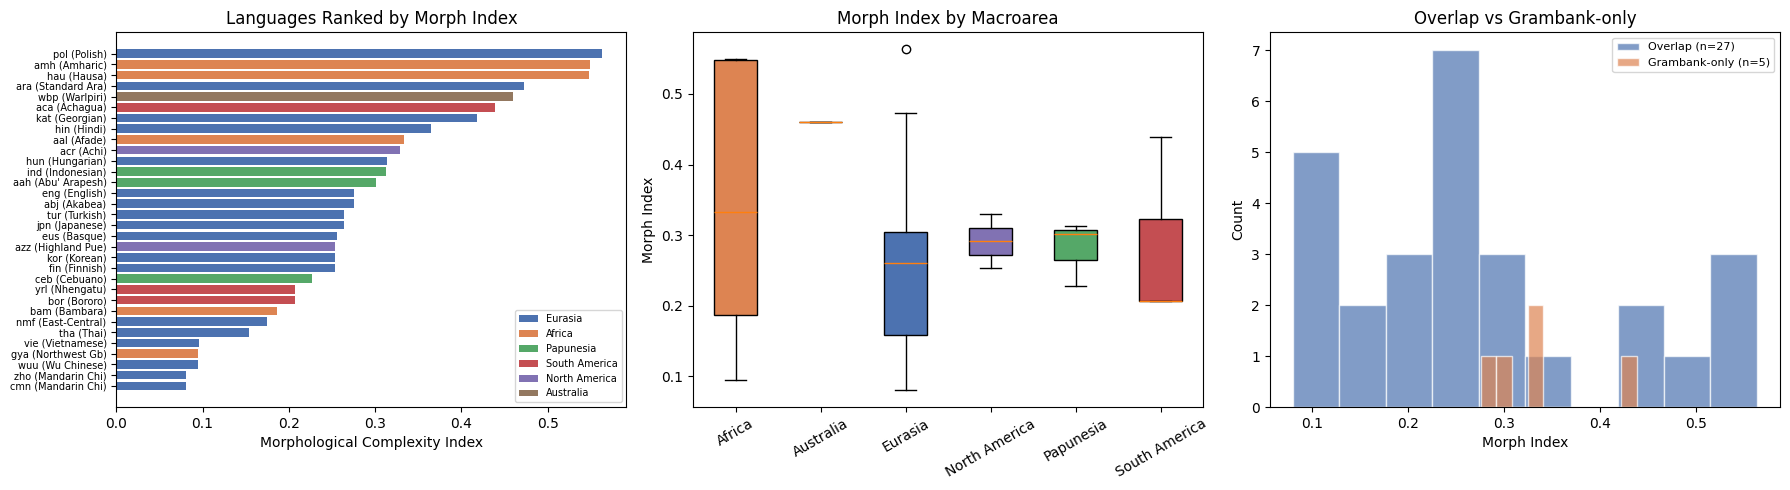

Saved: morph_complexity_overview.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Ranked morph index bar chart ---
ax = axes[0]
df_ranked = df_morph.sort_values("morph_index").reset_index(drop=True)
area_colors = {
    "Eurasia": "#4C72B0", "Africa": "#DD8452", "Papunesia": "#55A868",
    "South America": "#C44E52", "North America": "#8172B3", "Australia": "#937860",
    "": "#AAAAAA"
}
colors = [area_colors.get(a, "#AAAAAA") for a in df_ranked["macroarea"]]
ax.barh(range(len(df_ranked)), df_ranked["morph_index"], color=colors, edgecolor="none")
ax.set_yticks(range(len(df_ranked)))
ax.set_yticklabels([f"{r['iso3']} ({r['language'][:12]})" for _, r in df_ranked.iterrows()], fontsize=7)
ax.set_xlabel("Morphological Complexity Index")
ax.set_title("Languages Ranked by Morph Index")

# Legend for macroareas
from matplotlib.patches import Patch
used_areas = [a for a in area_colors if a in df_ranked["macroarea"].values]
legend_patches = [Patch(facecolor=area_colors[a], label=a) for a in used_areas]
ax.legend(handles=legend_patches, fontsize=7, loc="lower right")

# --- Plot 2: Box plot by macroarea ---
ax = axes[1]
areas_with_data = df_morph[df_morph["macroarea"] != ""].groupby("macroarea")["morph_index"].apply(list).to_dict()
if areas_with_data:
    area_labels = sorted(areas_with_data.keys())
    box_data = [areas_with_data[a] for a in area_labels]
    bp = ax.boxplot(box_data, tick_labels=area_labels, patch_artist=True, vert=True)
    for patch, label in zip(bp["boxes"], area_labels):
        patch.set_facecolor(area_colors.get(label, "#AAAAAA"))
    ax.set_ylabel("Morph Index")
    ax.set_title("Morph Index by Macroarea")
    ax.tick_params(axis="x", rotation=30)

# --- Plot 3: Overlap vs Grambank-only ---
ax = axes[2]
overlap_vals = df_morph[df_morph["fold"] == "overlap"]["morph_index"].values
gb_only_vals = df_morph[df_morph["fold"] == "all"]["morph_index"].values
if len(overlap_vals) > 0:
    ax.hist(overlap_vals, bins=10, alpha=0.7, label=f"Overlap (n={len(overlap_vals)})", color="#4C72B0", edgecolor="white")
if len(gb_only_vals) > 0:
    ax.hist(gb_only_vals, bins=10, alpha=0.7, label=f"Grambank-only (n={len(gb_only_vals)})", color="#DD8452", edgecolor="white")
ax.set_xlabel("Morph Index")
ax.set_ylabel("Count")
ax.set_title("Overlap vs Grambank-only")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("morph_complexity_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: morph_complexity_overview.png")